# EVA — VLM persona results analysis

**Dataset.** ~137k filtered ballots (~30 per image); voters carry birth year, region, gender, photographic level and eyesight. 6 axes. Scale: score 0-10, sub-axes 1-4.

**What this notebook compares.** The same real raters were replayed as VLM personas under three model-side conditions, each scored against every rater's *true* value:

| condition | directory | what it is |
|---|---|---|
| `persona · T=0` | `data/logs_t_0` | each real rater role-played, greedy decoding |
| `persona · T=0.7` | `data/logs_t_0.7` | same, temperature 0.7 requested |
| `blind · T=0.7` | `data/logs_blind` | one generic rater-agnostic prompt for every image (control) |

It asks four things: (1) do persona VLMs reproduce real ratings better than predict-the-mean baselines, (2) are they biased, (3) do they reproduce each image's *distribution* of human scores, and (4) does conditioning on *who* is rating add any rater-level signal over the blind control.

In [1]:
import glob
import json
import os
from itertools import combinations

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats

# --- palette: validated categorical slots (blue / aqua / amber) + chart chrome ---------
BLUE, AQUA, AMBER = "#2a78d6", "#1baf7a", "#d98a1f"
INK, SECONDARY, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
HUMAN_FILL = "#d9d7cd"                 # neutral reference fill for the real-rating histograms
GOOD, CRITICAL = "#0ca30c", "#d03b3b"
CORR_CMAP = LinearSegmentedColormap.from_list("red_gray_blue", ["#e34948", "#f0efec", "#2a78d6"])

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": BASELINE, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.labelcolor": SECONDARY, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlecolor": INK,
    "axes.labelsize": 10, "legend.fontsize": 9, "legend.frameon": False,
    "figure.dpi": 110, "lines.linewidth": 2, "font.size": 10,
})
pd.set_option("display.width", 170, "display.max_columns", 60, "display.float_format", lambda v: f"{v:.3f}")

In [2]:
# ---- dataset configuration (the only cell that differs between the three notebooks) ----
DATASET = "EVA"
STEM_FULL, STEM_BLIND = "eva_full", "eva_blind"
PRIMARY_DIM = "score"          # axis used for the headline per-image scatter
SCALE_LABEL = "score 0-10, sub-axes 1-4"
RATER_WORD  = "voter"

# label -> (log directory, filename stem).  Order fixes plotting order & colour slots.
CONDITIONS = {
    "persona · T=0":   ("../data/logs_t_0",   STEM_FULL),
    "persona · T=0.7": ("../data/logs_t_0.7", STEM_FULL),
    "blind · T=0.7":   ("../data/logs_blind", STEM_BLIND),
}
COND_COLOR = {"persona · T=0": BLUE, "persona · T=0.7": AQUA, "blind · T=0.7": AMBER}
print(f"{DATASET}: {len(CONDITIONS)} conditions ->", ", ".join(CONDITIONS))

EVA: 3 conditions -> persona · T=0, persona · T=0.7, blind · T=0.7


## Load the three conditions

Raw `(image, rater)` records live in the `*.part-*.json` chunks referenced by each shard manifest; per-rating metrics are recomputed here from the pooled raw records, while per-image EMD/KS and the human bootstrap floor are read from the precomputed `metrics` block (each image sits in exactly one shard, so they concatenate cleanly).

In [3]:
def _main_shards(dirp, stem):
    # the merged per-shard manifests, e.g. para_full.shard0of4.json -- NOT the .part-*.json chunks
    fs = sorted(glob.glob(os.path.join(dirp, f"{stem}.shard*of*.json")))
    return [f for f in fs if ".part-" not in f]


def load_condition(dirp, stem):
    """One condition -> raw ratings (wide df), pooled per-image table, config, axis grids.

    The manifest holds config + precomputed metrics + a list of result_parts; the raw
    (image, rater) records live in those .part-*.json files. Images never span shards
    (stratified by image), so per-image rows from every shard simply concatenate.
    """
    shards = _main_shards(dirp, stem)
    if not shards:
        raise FileNotFoundError(f"no shards matched {stem} under {dirp}")
    recs, per_image, grids, cfg = [], [], {}, None
    for mf in shards:
        d = json.load(open(mf))
        cfg = d  # config is identical across a condition's shards apart from the `shard` field
        for dim, dm in d["metrics"]["per_dimension"].items():
            grids.setdefault(dim, dm["distribution"]["score_grid"])
            per_image.extend({**row, "dim": dim} for row in dm["per_image"])
        for part in d["result_parts"]:
            for r in json.load(open(os.path.join(dirp, part))):
                recs.append({k: v for k, v in r.items() if k not in ("comment", "raw_response")})
    dims = [x["name"] if isinstance(x, dict) else x for x in cfg["dimensions"]]
    df = pd.DataFrame(recs)
    for dim in dims:                       # coerce so unparsed (None) predictions become NaN
        for pfx in ("gt_", "pred_"):
            df[pfx + dim] = pd.to_numeric(df[pfx + dim], errors="coerce")
    return dict(df=df, pimg=pd.DataFrame(per_image), cfg=cfg, dims=dims,
                grids=grids, n_shards=len(shards))


DATA = {label: load_condition(dirp, stem) for label, (dirp, stem) in CONDITIONS.items()}
DIMS = DATA["persona · T=0"]["dims"]
GRIDS = DATA["persona · T=0"]["grids"]
for lbl, d in DATA.items():               # every condition must share the same axes to be comparable
    assert d["dims"] == DIMS, f"{lbl} has different dimensions: {d['dims']}"

PERSONA_CONDS = [l for l, d in DATA.items() if not d["cfg"].get("persona_blind")]
BLIND_CONDS   = [l for l, d in DATA.items() if d["cfg"].get("persona_blind")]
print("axes:", ", ".join(DIMS))
print("persona conditions:", PERSONA_CONDS, "| blind:", BLIND_CONDS)

axes: score, visual, composition, quality, semantic, difficulty
persona conditions: ['persona · T=0', 'persona · T=0.7'] | blind: ['blind · T=0.7']


In [4]:
def overall_parse_rate(df, dims):
    cells = len(df) * len(dims)
    got = int(sum(df[f"pred_{d}"].notna().sum() for d in dims))
    return got / cells if cells else float("nan")

meta = pd.DataFrame({
    lbl: {
        "temperature": d["cfg"].get("temperature"),
        "top_k": d["cfg"].get("top_k"), "top_p": d["cfg"].get("top_p"),
        "persona_blind": d["cfg"].get("persona_blind"),
        "sampling": d["cfg"].get("sampling"), "seed": d["cfg"].get("seed"),
        "shards": d["n_shards"],
        "images": d["df"]["imageName"].nunique(),
        "raters": d["df"]["userId"].nunique(),
        "ratings": len(d["df"]),
        "parse_rate": round(overall_parse_rate(d["df"], DIMS), 4),
        "generated_at": d["cfg"].get("generated_at", "")[:19],
    }
    for lbl, d in DATA.items()
}).T
meta

,temperature,top_k,top_p,persona_blind,sampling,seed,shards,images,raters,ratings,parse_rate,generated_at
persona · T=0,0.000,None,None,None,stratified,0,4,4070,1094,136943,1.000,2026-07-07T05:07:53
persona · T=0.7,0.700,None,None,False,stratified,0,2,4000,1094,134576,1.000,2026-07-14T14:00:47
blind · T=0.7,0.700,None,None,True,stratified,0,4,4070,1094,136943,1.000,2026-07-09T03:44:24


In [5]:
# Persona vs blind must use different prompts, or the "blind" control is not a control.
p_lbl, b_lbl = PERSONA_CONDS[0], BLIND_CONDS[0]
p_cfg, b_cfg = DATA[p_lbl]["cfg"], DATA[b_lbl]["cfg"]
print(f"persona system prompt == blind system prompt ?  "
      f"{p_cfg['system_prompt_template'] == b_cfg['system_prompt_template']}")
print(f"persona question      == blind question      ?  {p_cfg['question'] == b_cfg['question']}\n")
print("--- persona system prompt (template) ---\n" + p_cfg["system_prompt_template"][:600])
print("\n--- blind system prompt ---\n" + b_cfg["system_prompt_template"][:600])
print("\n--- blind question ---\n" + b_cfg["question"][:400])

persona system prompt == blind system prompt ?  False
persona question      == blind question      ?  False

--- persona system prompt (template) ---
You are role-playing as one specific human participant in an online study of visual aesthetics. The participant is {description}

You are shown one photograph from the study. Judge it the way this exact person would: let their age, gender, cultural background, photography experience, and eyesight shape both what they notice and how critical or generous they are. Not every photo deserves a good score; be honest when a photo would bore or disappoint this person. Do not mention that you are an AI or that you are role-playing.

--- blind system prompt ---
You are an impartial, general-purpose judge of visual aesthetics.

You are shown one photograph from a study of visual aesthetics. Judge it on its own merits the way a typical viewer would, without adopting any particular person's perspective or taste. Not every photo deserves a good score; 

> ### ⚠️ Two caveats baked into these runs (from `CLAUDE.md`)
> 1. **Temperature did nothing.** `Qwen2-VL` ships `top_k=1, top_p=0.001`, and none of these para/eva/lapis runs override it, so decoding stayed **greedy even at T=0.7**. Treat `persona · T=0.7` as a second greedy run on a different image sample, not a sampling condition.
> 2. **Blind distribution metrics are invalid.** Because decoding is greedy and the blind prompt is identical across an image's raters, every rater gets a byte-identical answer → ~zero within-image spread. Blind **point** metrics (MAE/RMSE/bias/correlation) are fine; blind **EMD/KS/within-image** numbers are not, and are flagged where they appear.

## Shared analysis helpers

Rating-level metrics, per-image and within-image correlations, and grid-aware histograms — all operating on the wide raw frames.

In [6]:
def pairs(df, dim):
    # tidy (image, ground-truth, prediction) with unparsed predictions dropped
    s = df[["imageName", f"gt_{dim}", f"pred_{dim}"]].rename(
        columns={f"gt_{dim}": "gt", f"pred_{dim}": "pred"})
    return s.dropna()


def per_rating_metrics(df, dim):
    # rating-level agreement + the two persona-blind statistical baselines (predict a mean)
    p = pairs(df, dim)
    gt, pr = p["gt"].to_numpy(), p["pred"].to_numpy()
    err = pr - gt
    img_mean = p.groupby("imageName")["gt"].transform("mean").to_numpy()
    ok = pr.std() > 0 and gt.std() > 0
    return dict(
        n=len(p),
        mae=np.abs(err).mean(), rmse=np.sqrt((err ** 2).mean()), bias=err.mean(),
        pearson=stats.pearsonr(pr, gt)[0] if ok else np.nan,
        spearman=stats.spearmanr(pr, gt)[0] if ok else np.nan,
        base_mae_global=np.abs(gt - gt.mean()).mean(),   # predict one global mean for every rating
        base_mae_image=np.abs(gt - img_mean).mean(),     # predict each image's own human mean
        human_sd=gt.std(),
    )


def image_mean_corr(df, dim):
    # how well the model orders images (per-image mean prediction vs per-image human mean)
    g = pairs(df, dim).groupby("imageName").agg(h=("gt", "mean"), v=("pred", "mean"))
    if len(g) < 3 or g["v"].std() == 0:
        return np.nan
    return stats.pearsonr(g["v"], g["h"])[0]


def within_image_corr(df, dim, min_n=3):
    # for a FIXED image, does the model track which raters scored it higher? (rater-level signal)
    rs, n_pred_varies, n_img = [], 0, 0
    for _, g in pairs(df, dim).groupby("imageName"):
        if len(g) < min_n:
            continue
        n_img += 1
        pv = g["pred"].std() > 0
        n_pred_varies += pv
        if pv and g["gt"].std() > 0:
            r = stats.pearsonr(g["pred"], g["gt"])[0]
            if np.isfinite(r):
                rs.append(r)
    return dict(mean_r=np.mean(rs) if rs else np.nan, n_scored=len(rs),
                frac_pred_varies=(n_pred_varies / n_img) if n_img else np.nan, n_img=n_img)


def hist_on_grid(vals, grid):
    # normalised histogram; snap to the axis grid, but coarsen very fine grids (e.g. 0-100)
    grid = np.asarray(grid, float)
    vals = np.asarray(vals, float)
    if len(grid) > 25:
        edges = np.linspace(grid[0], grid[-1], 26)
        centers = 0.5 * (edges[:-1] + edges[1:])
    else:
        step = np.median(np.diff(grid)) if len(grid) > 1 else 1.0
        edges = np.concatenate([grid - step / 2, [grid[-1] + step / 2]])
        centers = grid
    h, _ = np.histogram(vals, bins=edges)
    tot = h.sum()
    return centers, (h / tot if tot else h), float(np.median(np.diff(centers)) if len(centers) > 1 else 1.0)


def grid_shape(n):
    ncol = 1 if n == 1 else (2 if n <= 4 else 3)
    return int(np.ceil(n / ncol)), ncol

## 1 · Agreement with real ratings

The core question. `base_mae_image` = predict each image's own human mean; `base_mae_global` = predict one global mean. Beating `base_mae_image` is the bar that matters — it is what the model must clear to be worth more than a lookup table of image averages.

In [7]:
# rating-level metrics for every (condition, axis); baselines are ground-truth-only so
# they are reported once (from the persona-T=0 task set, which the blind run shares exactly).
rows = []
for lbl, d in DATA.items():
    for dim in DIMS:
        m = per_rating_metrics(d["df"], dim)
        rows.append(dict(condition=lbl, axis=dim, n=m["n"], mae=m["mae"], rmse=m["rmse"],
                         bias=m["bias"], pearson=m["pearson"], spearman=m["spearman"],
                         base_mae_image=m["base_mae_image"], base_mae_global=m["base_mae_global"],
                         mae_vs_imagebase=m["mae"] / m["base_mae_image"]))
agree = pd.DataFrame(rows)
print("Rating-level agreement.  mae_vs_imagebase < 1  ==  beats 'predict the image's human mean'.\n")
agree.set_index(["axis", "condition"]).sort_index()

Rating-level agreement.  mae_vs_imagebase < 1  ==  beats 'predict the image's human mean'.



n   mae  rmse  bias  pearson  spearman  base_mae_image  base_mae_global  mae_vs_imagebase
axis        condition                                                                                                      
composition blind · T=0.7    136943 0.673 0.936 0.490    0.193     0.187           0.511            0.525             1.315
            persona · T=0    136943 0.547 0.810 0.235    0.126     0.120           0.511            0.525             1.069
            persona · T=0.7  134576 0.561 0.825 0.267    0.128     0.122           0.511            0.525             1.098
difficulty  blind · T=0.7    136943 0.661 0.886 0.484    0.013     0.013           0.357            0.351             1.852
            persona · T=0    136943 0.507 0.769 0.255    0.030     0.029           0.357            0.351             1.421
            persona · T=0.7  134576 0.528 0.788 0.282    0.017     0.016           0.357            0.351             1.481
quality     blind · T=0.7    136943 0.868 1.084 0.827    0.220     0.205           0.410            0.436             2.118
            persona · T=0    136943 0.495 0.781 0.336    0.156     0.147           0.410            0.436             1.209
            persona · T=0.7  134576 0.528 0.811 0.386    0.162     0.153           0.410            0.435             1.288
score       blind · T=0.7    136943 1.761 2.298 1.030    0.323     0.315           1.423            1.631             1.237
            persona · T=0    136943 1.669 2.197 0.737    0.276     0.277           1.423            1.631             1.173
            persona · T=0.7  134576 1.697 2.234 0.869    0.275     0.280           1.423            1.631             1.192
semantic    blind · T=0.7    136943 0.668 0.932 0.553    0.206     0.204           0.449            0.482             1.489
            persona · T=0    136943 0.503 0.784 0.291    0.140     0.137           0.449            0.482             1.120
            persona · T=0.7  134576 0.523 0.804 0.326    0.138     0.137           0.449            0.483             1.164
visual      blind · T=0.7    136943 0.933 1.165 0.887    0.204     0.198           0.495            0.535             1.884
            persona · T=0    136943 0.936 1.167 0.890    0.210     0.206           0.495            0.535             1.890
            persona · T=0.7  134576 0.960 1.187 0.924    0.206     0.201           0.495            0.535             1.939

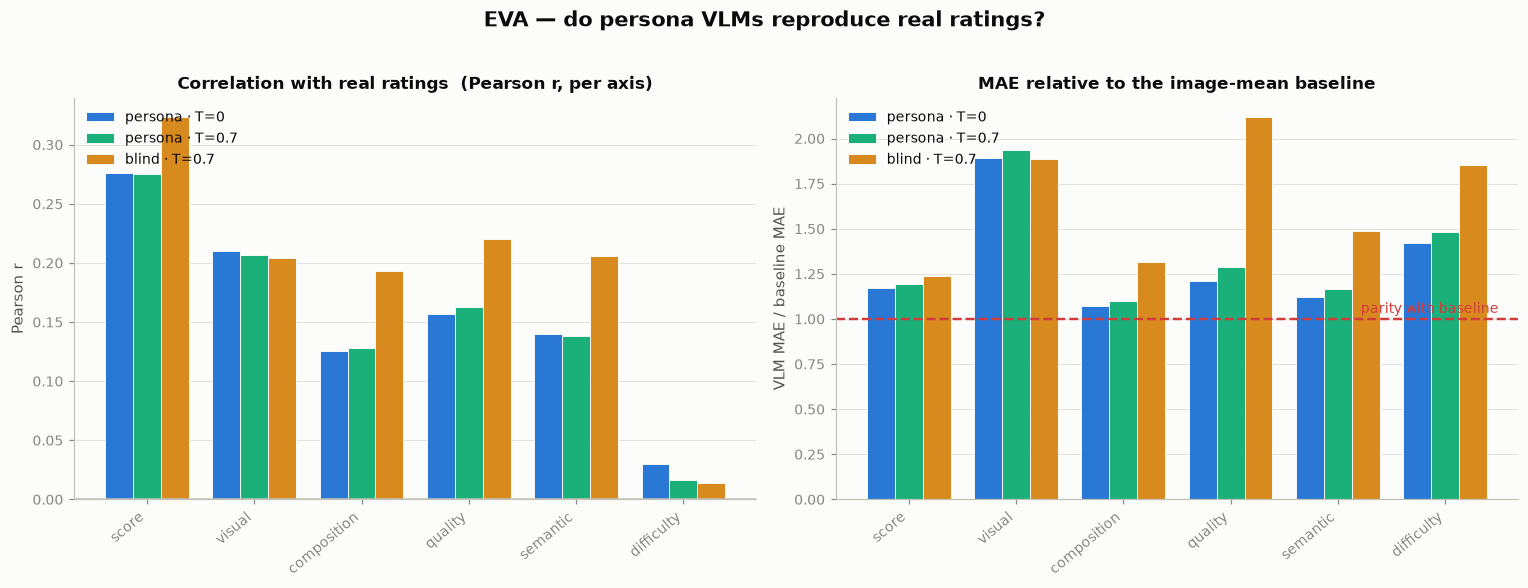

In [8]:
# Two scale-free headline views: correlation (higher=better) and MAE relative to the
# image-mean baseline (below the red line = the model actually beats the naive baseline).
x = np.arange(len(DIMS)); w = 0.26
fig, (axc, axr) = plt.subplots(1, 2, figsize=(14, 5.2))
for i, lbl in enumerate(DATA):
    pe = [per_rating_metrics(DATA[lbl]["df"], dim)["pearson"] for dim in DIMS]
    rt = [r["mae"] / r["base_mae_image"] for r in (per_rating_metrics(DATA[lbl]["df"], dim) for dim in DIMS)]
    off = (i - 1) * w
    axc.bar(x + off, pe, w, color=COND_COLOR[lbl], label=lbl, edgecolor=SURFACE, linewidth=0.6)
    axr.bar(x + off, rt, w, color=COND_COLOR[lbl], label=lbl, edgecolor=SURFACE, linewidth=0.6)
axc.set_title("Correlation with real ratings  (Pearson r, per axis)")
axc.set_ylabel("Pearson r"); axc.axhline(0, color=BASELINE, lw=1)
axr.set_title("MAE relative to the image-mean baseline")
axr.set_ylabel("VLM MAE / baseline MAE")
axr.axhline(1.0, color=CRITICAL, lw=1.6, ls="--")
axr.annotate("parity with baseline", xy=(len(DIMS) - 0.5, 1.0), xytext=(0, 4),
             textcoords="offset points", ha="right", color=CRITICAL, fontsize=9)
for ax in (axc, axr):
    ax.set_xticks(x, DIMS, rotation=40, ha="right"); ax.xaxis.grid(False)
    ax.legend(loc="upper left", ncol=1)
fig.suptitle(f"{DATASET} — do persona VLMs reproduce real ratings?", fontsize=14,
             fontweight="bold", color=INK, y=1.02)
fig.tight_layout(); plt.show()

## 2 · Bias & score distributions

Where the model puts its scores versus where humans put theirs.

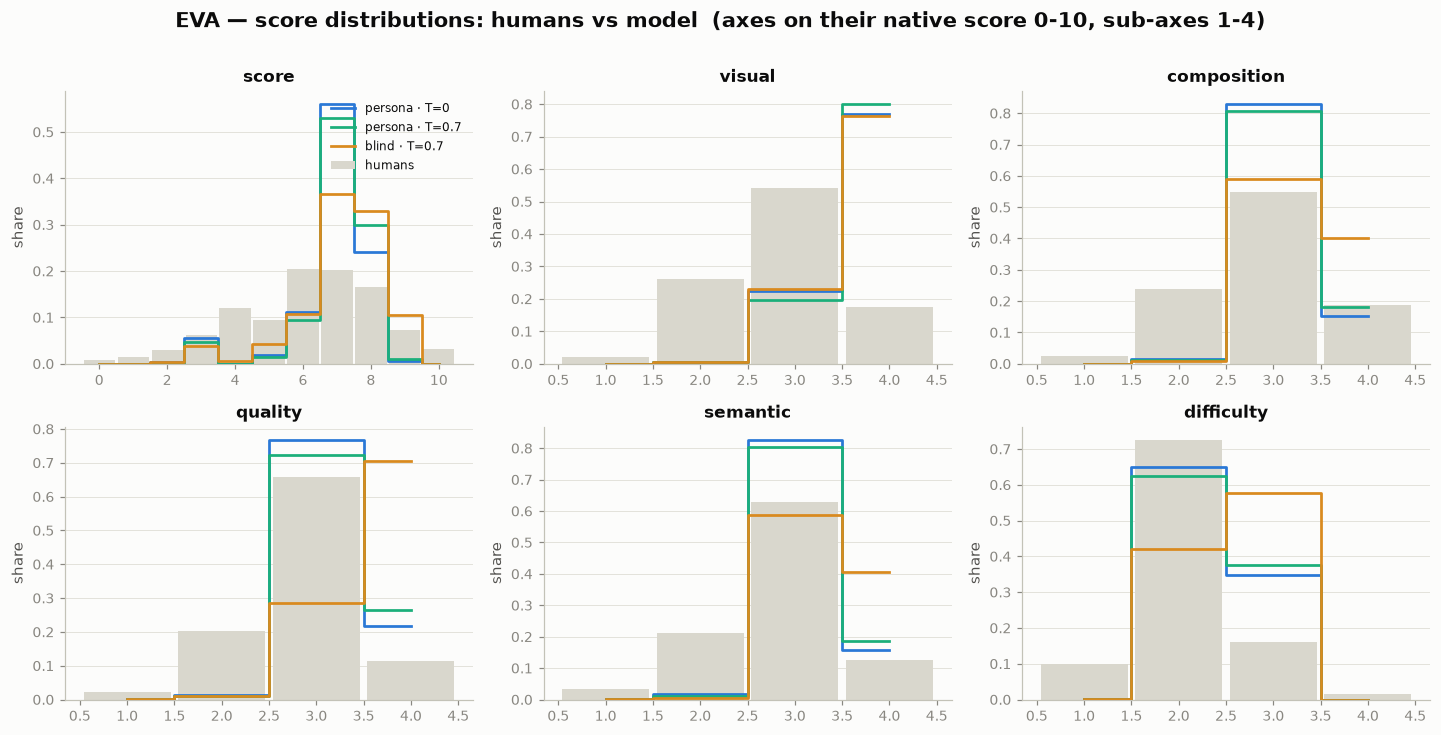

In [9]:
# Real-rating distribution (grey) vs each condition's prediction distribution, per axis.
nr, nc = grid_shape(len(DIMS))
fig, axes = plt.subplots(nr, nc, figsize=(4.4 * nc, 3.3 * nr), squeeze=False)
human_df = DATA["persona · T=0"]["df"]          # human ratings (shared with the blind task set)
for ax, dim in zip(axes.flat, DIMS):
    grid = GRIDS[dim]
    hc, hh, hw = hist_on_grid(pairs(human_df, dim)["gt"], grid)
    ax.bar(hc, hh, width=hw * 0.92, color=HUMAN_FILL, label="humans", zorder=1)
    for lbl, d in DATA.items():
        c, h, _ = hist_on_grid(pairs(d["df"], dim)["pred"], grid)
        ax.step(c, h, where="mid", color=COND_COLOR[lbl], lw=1.8, label=lbl, zorder=3)
    ax.set_title(dim); ax.xaxis.grid(False); ax.set_ylabel("share")
for ax in axes.flat[len(DIMS):]:
    ax.set_visible(False)
axes.flat[0].legend(loc="upper right", fontsize=8)
fig.suptitle(f"{DATASET} — score distributions: humans vs model  (axes on their native {SCALE_LABEL})",
             fontsize=14, fontweight="bold", color=INK, y=1.005)
fig.tight_layout(); plt.show()

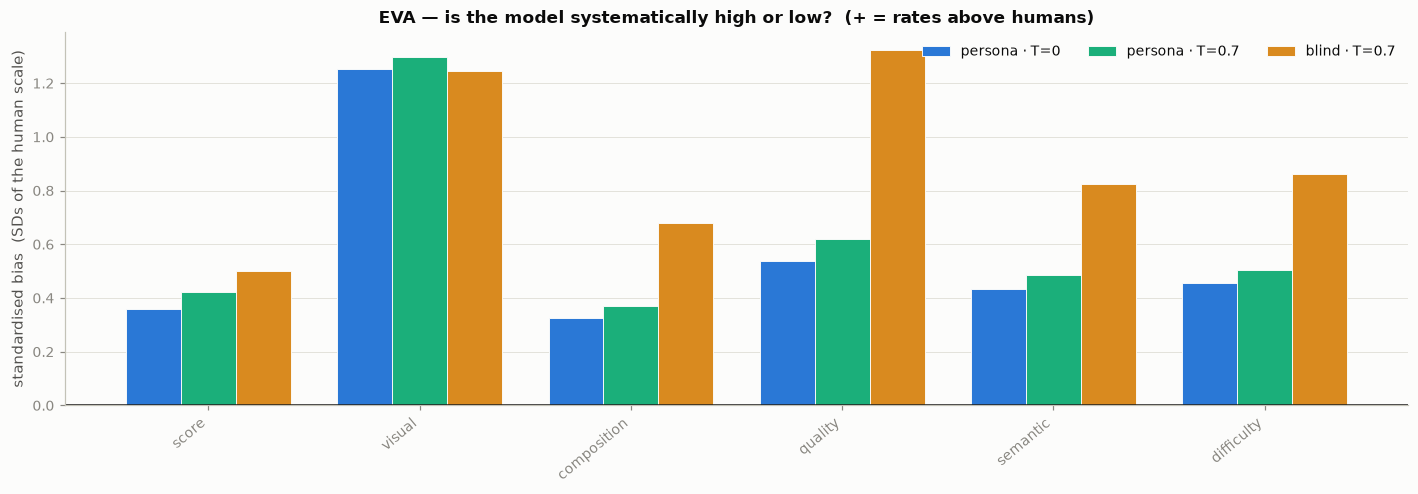

In [10]:
# Standardised mean bias = mean(pred - human) / sd(human), so axes on different scales compare.
x = np.arange(len(DIMS)); w = 0.26
fig, ax = plt.subplots(figsize=(13, 4.6))
for i, lbl in enumerate(DATA):
    sb = []
    for dim in DIMS:
        m = per_rating_metrics(DATA[lbl]["df"], dim)
        sb.append(m["bias"] / m["human_sd"] if m["human_sd"] else np.nan)
    ax.bar(x + (i - 1) * w, sb, w, color=COND_COLOR[lbl], label=lbl, edgecolor=SURFACE, linewidth=0.6)
ax.axhline(0, color=INK, lw=1)
ax.set_xticks(x, DIMS, rotation=40, ha="right"); ax.xaxis.grid(False)
ax.set_ylabel("standardised bias  (SDs of the human scale)")
ax.set_title(f"{DATASET} — is the model systematically high or low?  (+ = rates above humans)")
ax.legend(ncol=3, loc="best"); fig.tight_layout(); plt.show()

## 3 · Per-image distribution match

Beyond the mean: does the model reproduce the *spread* of scores a single image draws from its raters? Compared against a human bootstrap floor (how far a resample of the humans lands from the humans). Persona conditions only are interpretable here.

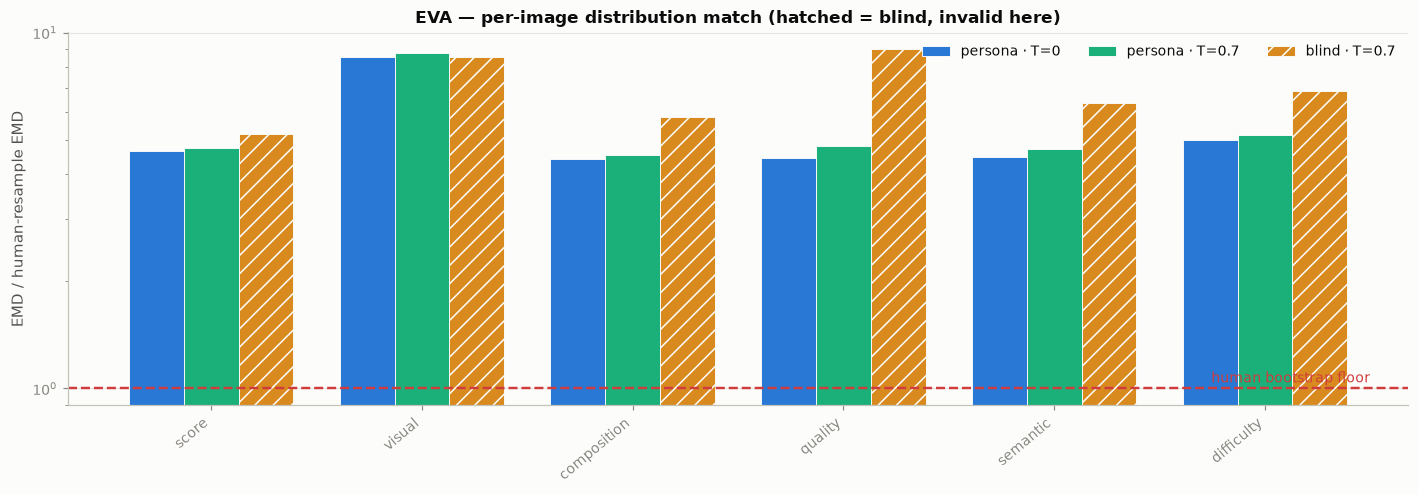

emd  human_floor  emd_ratio    ks  vlm_std  human_std
axis        condition                                                              
composition blind · T=0.7   0.661        0.114      5.808 0.498    0.030      0.659
            persona · T=0   0.504        0.114      4.424 0.361    0.097      0.659
            persona · T=0.7 0.516        0.114      4.533 0.371    0.101      0.659
difficulty  blind · T=0.7   0.636        0.093      6.854 0.534    0.078      0.532
            persona · T=0   0.464        0.093      4.996 0.371    0.130      0.532
            persona · T=0.7 0.480        0.093      5.169 0.385    0.142      0.532
quality     blind · T=0.7   0.862        0.096      8.986 0.701    0.023      0.559
            persona · T=0   0.426        0.096      4.436 0.320    0.203      0.559
            persona · T=0.7 0.459        0.096      4.788 0.347    0.211      0.559
score       blind · T=0.7   1.746        0.336      5.196 0.625    0.038      1.781
            persona · T=0   1.565        0.336      4.657 0.549    0.200      1.781
            persona · T=0.7 1.598        0.336      4.753 0.563    0.195      1.781
semantic    blind · T=0.7   0.660        0.104      6.345 0.524    0.026      0.600
            persona · T=0   0.467        0.104      4.485 0.351    0.096      0.600
            persona · T=0.7 0.489        0.104      4.694 0.370    0.096      0.600
visual      blind · T=0.7   0.930        0.109      8.552 0.708    0.011      0.634
            persona · T=0   0.926        0.109      8.516 0.704    0.043      0.634
            persona · T=0.7 0.953        0.109      8.758 0.722    0.038      0.634

In [11]:
# Per-image distribution match vs the human bootstrap floor.  emd_ratio = model EMD /
# human-resample EMD; >1 means the model's per-image spread is further from the humans than
# humans are from a resample of themselves.  Blind is shown but is invalid here (decoding
# collapse -> ~zero within-image spread; see the caveat cell).
rows = []
for lbl, d in DATA.items():
    pi = d["pimg"]
    for dim in DIMS:
        s = pi[pi["dim"] == dim]
        if s.empty:
            continue
        rows.append(dict(condition=lbl, axis=dim,
                         emd=s["emd"].mean(), human_floor=s["human_resample_emd"].mean(),
                         emd_ratio=s["emd"].mean() / s["human_resample_emd"].mean(),
                         ks=s["ks"].mean(), vlm_std=s["vlm_std"].mean(), human_std=s["human_std"].mean()))
emd = pd.DataFrame(rows)

x = np.arange(len(DIMS)); w = 0.26
fig, ax = plt.subplots(figsize=(13, 4.6))
for i, lbl in enumerate(DATA):
    sub = emd[emd["condition"] == lbl].set_index("axis").reindex(DIMS)
    ax.bar(x + (i - 1) * w, sub["emd_ratio"], w, color=COND_COLOR[lbl], label=lbl,
           edgecolor=SURFACE, linewidth=0.6, hatch="//" if lbl in BLIND_CONDS else None)
ax.axhline(1.0, color=CRITICAL, lw=1.6, ls="--")
ax.annotate("human bootstrap floor", xy=(len(DIMS) - 0.5, 1.0), xytext=(0, 4),
            textcoords="offset points", ha="right", color=CRITICAL, fontsize=9)
ax.set_xticks(x, DIMS, rotation=40, ha="right"); ax.xaxis.grid(False)
ax.set_ylabel("EMD / human-resample EMD"); ax.set_yscale("log")
ax.set_title(f"{DATASET} — per-image distribution match (hatched = blind, invalid here)")
ax.legend(ncol=3, loc="best"); fig.tight_layout(); plt.show()
emd.set_index(["axis", "condition"]).sort_index()

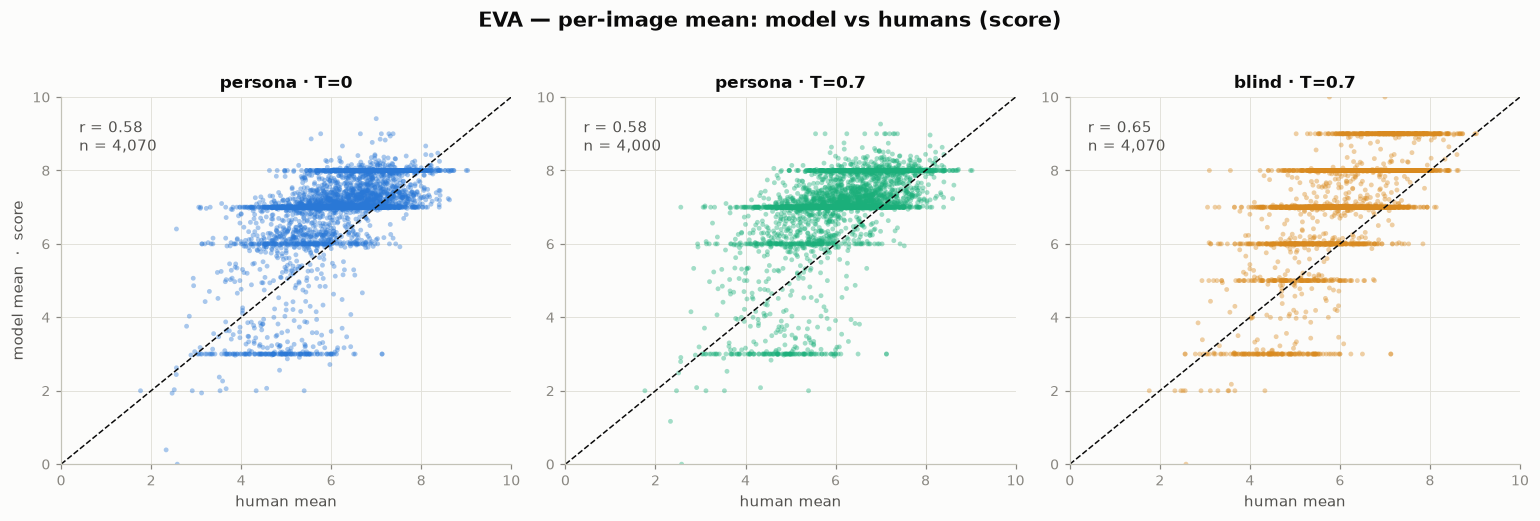

In [12]:
# Image ordering on the headline axis: each dot is one image, x=human mean, y=model mean.
fig, axes = plt.subplots(1, len(DATA), figsize=(4.7 * len(DATA), 4.6), squeeze=False)
grid = GRIDS[PRIMARY_DIM]; lo, hi = grid[0], grid[-1]
for ax, (lbl, d) in zip(axes.flat, DATA.items()):
    s = d["pimg"][d["pimg"]["dim"] == PRIMARY_DIM]
    ax.scatter(s["human_mean"], s["vlm_mean"], s=10, color=COND_COLOR[lbl], alpha=0.4,
               edgecolor="none")
    ax.plot([lo, hi], [lo, hi], color=INK, lw=1, ls="--")
    r = image_mean_corr(d["df"], PRIMARY_DIM)
    ax.annotate(f"r = {r:.2f}\nn = {len(s):,}", xy=(0.04, 0.94), xycoords="axes fraction",
                va="top", fontsize=10, color=SECONDARY)
    ax.set_title(lbl); ax.set_xlabel("human mean"); ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
axes.flat[0].set_ylabel(f"model mean  ·  {PRIMARY_DIM}")
fig.suptitle(f"{DATASET} — per-image mean: model vs humans ({PRIMARY_DIM})", fontsize=14,
             fontweight="bold", color=INK, y=1.02)
fig.tight_layout(); plt.show()

## 4 · Does the persona add rater-level signal?

The whole premise is that *who* rates changes the score. This measures it directly: within a single image, does the model's per-rater prediction track which raters actually scored higher? If this is ~0, the model is really an image-level judge wearing persona costumes.

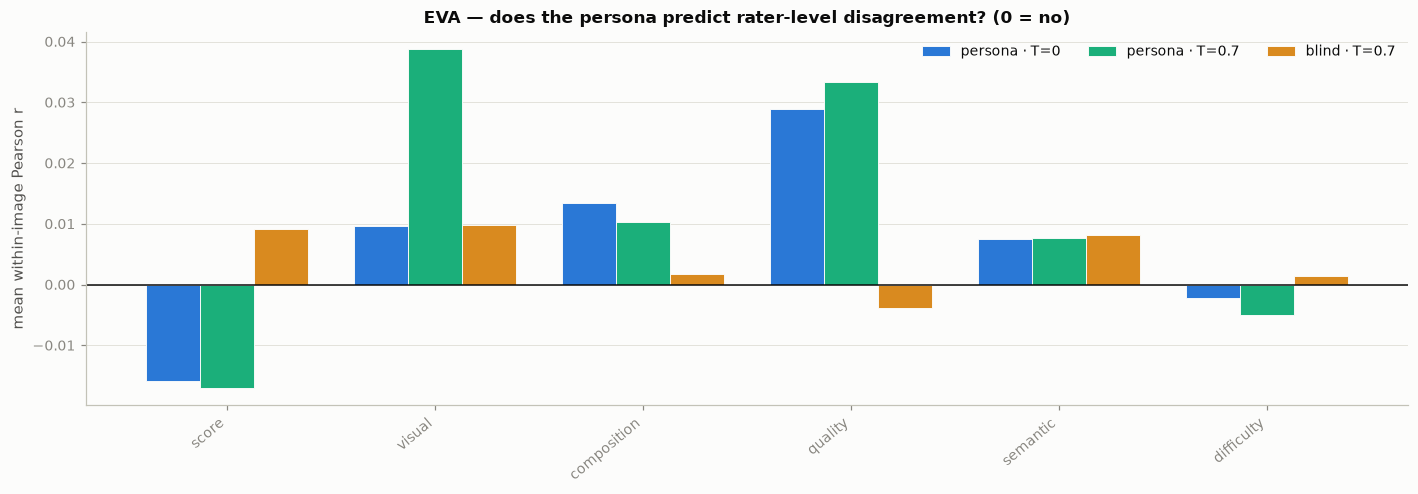

mean_within_r  frac_pred_varies  images_scored  images
axis        condition                                                              
composition blind · T=0.7            0.002             0.082            332    4070
            persona · T=0            0.013             0.281           1142    4070
            persona · T=0.7          0.010             0.286           1144    4000
difficulty  blind · T=0.7            0.001             0.212            862    4070
            persona · T=0           -0.002             0.376           1530    4070
            persona · T=0.7         -0.005             0.406           1624    4000
quality     blind · T=0.7           -0.004             0.066            270    4070
            persona · T=0            0.029             0.579           2356    4070
            persona · T=0.7          0.033             0.583           2333    4000
score       blind · T=0.7            0.009             0.103            421    4070
            persona · T=0           -0.016             0.487           1983    4070
            persona · T=0.7         -0.017             0.471           1886    4000
semantic    blind · T=0.7            0.008             0.071            288    4070
            persona · T=0            0.008             0.275           1120    4070
            persona · T=0.7          0.008             0.274           1097    4000
visual      blind · T=0.7            0.010             0.031            126    4070
            persona · T=0            0.010             0.133            542    4070
            persona · T=0.7          0.039             0.117            468    4000

In [13]:
# Does conditioning on WHO is rating add signal? For each image, correlate the model's
# per-rater prediction with that rater's true score, then average over images. ~0 means the
# model gives essentially one answer per image regardless of the persona it was handed.
rows = []
for lbl, d in DATA.items():
    for dim in DIMS:
        w = within_image_corr(d["df"], dim)
        rows.append(dict(condition=lbl, axis=dim, mean_within_r=w["mean_r"],
                         frac_pred_varies=w["frac_pred_varies"],
                         images_scored=w["n_scored"], images=w["n_img"]))
within = pd.DataFrame(rows)

x = np.arange(len(DIMS)); w = 0.26
fig, ax = plt.subplots(figsize=(13, 4.6))
for i, lbl in enumerate(DATA):
    sub = within[within["condition"] == lbl].set_index("axis").reindex(DIMS)
    ax.bar(x + (i - 1) * w, sub["mean_within_r"], w, color=COND_COLOR[lbl], label=lbl,
           edgecolor=SURFACE, linewidth=0.6)
ax.axhline(0, color=INK, lw=1)
ax.set_xticks(x, DIMS, rotation=40, ha="right"); ax.xaxis.grid(False)
ax.set_ylabel("mean within-image Pearson r")
ax.set_title(f"{DATASET} — does the persona predict rater-level disagreement? (0 = no)")
ax.legend(ncol=3, loc="best"); fig.tight_layout(); plt.show()
within.set_index(["axis", "condition"]).sort_index()

## 5 · Do the axes collapse?

Cross-axis correlation of per-image mean predictions. Uniformly high r ⇒ the model is emitting one latent judgement dressed up as several axes.

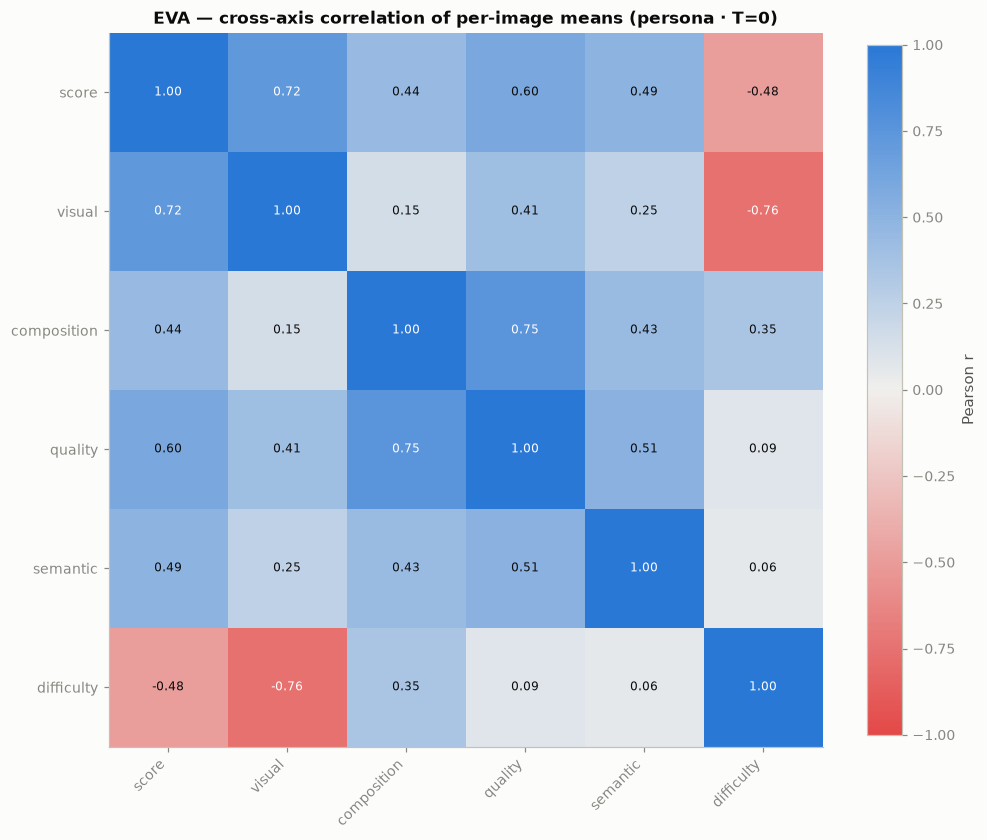

mean off-diagonal r: 0.267


In [14]:
# Do the axes measure different things, or collapse to one latent judgement?
# Pearson r between per-image MEAN predictions across axes (persona-T=0).
if len(DIMS) >= 2:
    d = DATA["persona · T=0"]
    means = pd.DataFrame({dim: pairs(d["df"], dim).groupby("imageName")["pred"].mean() for dim in DIMS})
    corr = means.corr()
    fig, ax = plt.subplots(figsize=(1.05 * len(DIMS) + 3, 1.0 * len(DIMS) + 2.5))
    im = ax.imshow(corr, cmap=CORR_CMAP, vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(corr)), corr.index)
    for a in range(len(corr)):
        for b in range(len(corr)):
            v = corr.iat[a, b]
            ax.annotate(f"{v:.2f}", (b, a), ha="center", va="center", fontsize=8,
                        color="#ffffff" if abs(v) > 0.62 else INK)
    ax.grid(False); ax.set_title(f"{DATASET} — cross-axis correlation of per-image means (persona · T=0)")
    fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")
    fig.tight_layout(); plt.show()
    print("mean off-diagonal r:", round(corr.where(~np.eye(len(corr), dtype=bool)).stack().mean(), 3))
else:
    print(f"{DATASET} has a single axis ({DIMS[0]}) — no cross-axis structure to show.")

## Verdict

In [15]:
# Printed, data-driven summary (no hand-typed numbers).
def block(lbl):
    d = DATA[lbl]
    m = {dim: per_rating_metrics(d["df"], dim) for dim in DIMS}
    beat = [dim for dim in DIMS if m[dim]["mae"] < m[dim]["base_mae_image"]]
    wr = np.nanmean([within_image_corr(d["df"], dim)["mean_r"] for dim in DIMS])
    return dict(
        mean_mae_ratio=np.mean([m[dim]["mae"] / m[dim]["base_mae_image"] for dim in DIMS]),
        mean_pearson=np.nanmean([m[dim]["pearson"] for dim in DIMS]),
        axes_beating_image_baseline=f"{len(beat)}/{len(DIMS)}",
        mean_within_image_r=wr,
    )

print(f"===== {DATASET}: headline =====")
summary = pd.DataFrame({lbl: block(lbl) for lbl in DATA}).T
print(summary.to_string())
print("\nReadout:")
print(" - mean_mae_ratio > 1  => on average worse than just predicting each image's human mean.")
print(" - mean_pearson       => image-ordering signal (moderate is typical; that lives at image level).")
print(" - mean_within_image_r ~ 0 => persona conditioning barely predicts rater-to-rater disagreement.")

===== EVA: headline =====


                mean_mae_ratio mean_pearson axes_beating_image_baseline mean_within_image_r
persona · T=0            1.314        0.156                         0/6               0.007
persona · T=0.7          1.360        0.155                         0/6               0.011
blind · T=0.7            1.649        0.193                         0/6               0.004

Readout:
 - mean_mae_ratio > 1  => on average worse than just predicting each image's human mean.
 - mean_pearson       => image-ordering signal (moderate is typical; that lives at image level).
 - mean_within_image_r ~ 0 => persona conditioning barely predicts rater-to-rater disagreement.


### Caveats to keep attached to these numbers
- Temperature was inert (greedy decoding); `T=0` and `T=0.7` differ only by image sample, so their gap is a reproducibility check, not a sampling effect.
- Blind EMD/KS/within-image spread are artefacts of the decoding collapse, not taste.
- Baselines (`base_mae_*`) are ground-truth-only oracles — they see the human means the model never does; clearing them is a high bar by design.
- MAE is on each axis's native scale; cross-axis comparisons use the scale-free views (Pearson r, MAE-vs-baseline ratio, standardised bias).